In [46]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [47]:
class Die:
    def __init__(self):
        self.sides = 6

    def roll(self):
        return random.randint(1, self.sides)
    
    def __del__(self):
        pass

In [48]:
class DiceBatch:
    def __init__(self):
        self.dice = [Die() for _ in range(3)]

    def roll_all(self):
        rolls = [die.roll() for die in self.dice]
        return rolls

In [49]:
class DiceGame:
    def __init__(self):
        self.player1 = DiceBatch()
        self.player2 = DiceBatch()

        self.score1 = 0
        self.score2 = 0

        self.history = []

In [50]:
def play_round(self):
    rolls1 = self.player1.roll_all()
    rolls2 = self.player2.roll_all()

    sum1 = sum(rolls1)
    sum2 = sum(rolls2)

    triple1_p1 = rolls1 == [1,1,1]
    triple1_p2 = rolls2 == [1,1,1]

    round_score1 = 0
    round_score2 = 0

    if triple1_p1:
        round_score1 += 1
    if triple1_p2:
        round_score2 += 1
    
    if not triple1_p1 and not triple1_p2:
        if sum1 > sum2:
            round_score1 = 1
        elif sum2 > sum1:
            round_score2 = 1
        else:
            round_score1 = 0.5
            round_score2 = 0.5

    self.score1 += round_score1
    self.score2 += round_score2

    self.history.append({
        "p1_rolls": rolls1,
        "p2_rolls": rolls2,
        "p1_sum": sum1,
        "p2_sum": sum2,
        "score_1": self.score1,
        "score_2": self.score2
    })

def play_game(self):
    while True:
        self.play_round()
        if self.score1 >= 5 or self.score2 >= 5:
            if self.score1 != self.score2:
                break
            return 1 if self.score1 > self.score2 else 2

In [ ]:
games = 50
player1_wins = 0
all_rolls = []
winner_rolls = []
loser_rolls = []

for _ in range(games):
    game = DiceGame()
    winner = game.play_game()

AttributeError: 'DiceGame' object has no attribute 'play_game'

In [52]:
if winner == 1:
    player1_wins += 1

for round_data in game.history:
    all_rolls.extend(round_data["p1_rolls"])
    all_rolls.extend(round_data["p2_rolls"])

In [53]:
probability = player1_wins / games
print("Player 1 wins probs", probability)

Player 1 wins probs 0.0


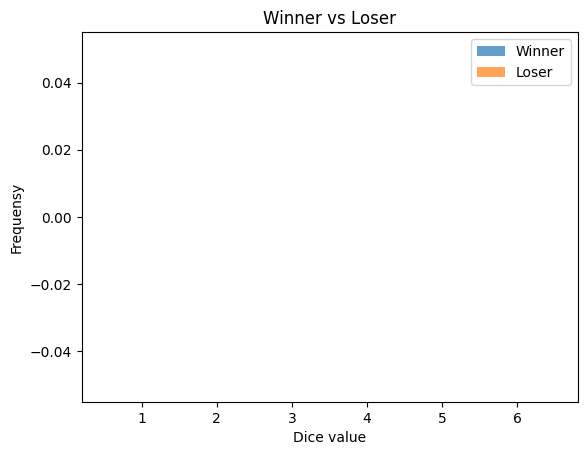

In [54]:
plt.hist(winner_rolls, bins=np.arange(1,8)-0.5, alpha=0.7, label="Winner")
plt.hist(loser_rolls, bins=np.arange(1,8)-0.5, alpha=0.7, label="Loser")
plt.xlabel("Dice value")
plt.ylabel("Frequensy")
plt.legend()
plt.title("Winner vs Loser")
plt.show()

In [55]:
sample_game = DiceGame()
sample_game.play_game()

p1_scores = [r["score1"] for r in sample_game.history]
p2_scores = [r["score2"] for r in sample_game.history]

plt.plot(p1_scores, label="Player 1")
plt.plot(p1_scores, label="Player 2")
plt.xlabel("Round")
plt.ylabel("Cumulative score")
plt.legend()
plt.title("Cumulative point")
plt.show()

AttributeError: 'DiceGame' object has no attribute 'play_game'

In [ ]:
observed = [all_rolls.count(i) for i in range(1, 7)]
expected = [len(all_rolls) / 6] * 6
chi1 , p = stats.chisquare(observed, expected)

print("Chi-square p-alue:", p)

In [ ]:
sums = []
for _ in range(500):
    batch = DiceBatch()
    sums.append(sum(batch.roll_all()))
stat, p = stats.shapiro(sums)
print("Shapiro p-value:", p)